# Car Crash Severity Prediction

**Course:** NETW 1013 — Machine Learning  
**Institution:** German University in Cairo, Faculty of Information Engineering and Technology  

## Project Overview

This notebook develops and evaluates machine learning classifiers to predict the **severity of a car crash** (`Minor Injury`, `Severe Injury`, or `Fatal`) from structured crash-related features such as crash speed, impact angle, weather, road conditions, driver characteristics, and vehicle state.

The pipeline below covers every required deliverable:

1. **Exploratory Data Analysis (EDA)** — shape, types, missing values, target distribution, numerical/categorical feature relationships with the target.
2. **Pre-processing** — missing-value handling, encoding of categorical variables, scaling of numerical features.
3. **All five mandatory classifiers** — K-Nearest Neighbours, Decision Tree, Random Forest, Logistic Regression, Naïve Bayes.
4. **One additional model** — Gradient Boosting (beyond the course content) to push performance further.
5. **Evaluation** — accuracy, macro-F1, weighted-F1, per-class precision/recall, and confusion matrices for every model, with written commentary.
6. **Final model** — the best classifier is re-trained on the **full** training set and used to generate predictions on the test set for Kaggle submission.


## 1. Imports and Setup

We import pandas / numpy for data wrangling, matplotlib / seaborn for visualisation, and the relevant scikit-learn modules for modelling and evaluation. A random seed is fixed so all results are reproducible.

In [ ]:
# Standard scientific Python stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# scikit-learn — preprocessing, models, evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Mandatory classifiers
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plotting defaults
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
warnings.filterwarnings("ignore")

print("Setup complete.")

Setup complete.


## 2. Loading the Data

We load the training and test sets provided through the Kaggle competition. The training set contains the target column `Severity`; the test set is what we will eventually submit predictions for on Kaggle.

In [ ]:
# Paths to the competition data
TRAIN_PATH = "/mnt/user-data/uploads/car_crash_train.csv"
TEST_PATH  = "/mnt/user-data/uploads/car_crash_test.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(f"Training set shape: {train_df.shape}")
print(f"Test set shape:     {test_df.shape}")

Training set shape: (4000, 19)
Test set shape:     (1000, 19)


In [ ]:
# First five rows of the training data
train_df.head()

,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m),Severity
0,182,69,Yes,No,Clear,Dry,Rollover,Sedan,5,Good,Good,23,11,0.025314,NaN,Morning,Low,213,Minor Injury
1,192,73,Yes,No,Clear,Dry,Head-on,Truck,3,Good,Good,29,27,0.002372,Phone,Morning,Medium,426,Minor Injury
2,114,77,No,Yes,Clear,Dry,Head-on,Sedan,16,Good,Worn out,73,45,0.000483,NaN,Morning,Medium,175,Minor Injury
3,93,14,No,Yes,Clear,Dry,Rear-end,Truck,14,Worn out,Worn out,27,18,0.176578,NaN,Afternoon,Medium,82,Minor Injury
4,170,96,No,Yes,Clear,Dry,Side impact,SUV,15,Good,Good,70,27,0.065696,Other,Morning,Medium,96,Severe Injury


## 3. Exploratory Data Analysis (EDA)

EDA is the most important step before modelling — it tells us about data types, missing values, class balance, and which features look promising. We work through the following:

1. Column types and overall structure
2. Missing values
3. Target class distribution (is the dataset balanced?)
4. Distributions of numerical features
5. Distributions of categorical features
6. Relationship between each feature and `Severity`
7. Correlation among numerical features

### 3.1 Column types and summary statistics

In [ ]:
# Compact summary of dtypes and non-null counts
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Crash Speed (km/h)         4000 non-null   int64  
 1   Impact Angle (degrees)     4000 non-null   int64  
 2   Airbag Deployed            4000 non-null   str    
 3   Seatbelt Used              4000 non-null   str    
 4   Weather Conditions         4000 non-null   str    
 5   Road Conditions            4000 non-null   str    
 6   Crash Type                 4000 non-null   str    
 7   Vehicle Type               4000 non-null   str    
 8   Vehicle Age (years)        4000 non-null   int64  
 9   Brake Condition            4000 non-null   str    
 10  Tire Condition             4000 non-null   str    
 11  Driver Age                 4000 non-null   int64  
 12  Driver Experience (years)  4000 non-null   int64  
 13  Alcohol Level (BAC%)       4000 non-null   float64
 14  Dis

In [ ]:
# Statistical summary of numerical columns
train_df.describe()

,Crash Speed (km/h),Impact Angle (degrees),Vehicle Age (years),Driver Age,Driver Experience (years),Alcohol Level (BAC%),Visibility Distance (m)
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,110.999750,89.979750,9.445500,48.698750,24.723000,0.101216,247.583500
std,52.227839,51.301514,5.718147,17.815972,14.211818,0.057820,143.478155
min,20.000000,0.000000,0.000000,18.000000,0.000000,0.000054,10.000000
25%,66.000000,45.000000,5.000000,34.000000,13.000000,0.050630,120.000000
50%,112.000000,89.500000,9.000000,49.000000,25.000000,0.101574,244.000000
75%,157.000000,134.000000,14.000000,64.000000,37.000000,0.151783,372.000000
max,199.000000,179.000000,19.000000,79.000000,49.000000,0.199936,499.000000


**Observations:**

- 19 columns in total: 7 numerical and 12 of object/string type, including the target `Severity`.
- 4,000 rows in train, 1,000 in test.
- Numerical ranges look plausible: Crash Speed 20–199 km/h, Driver Age up to 80+ years, Alcohol BAC% 0–~0.4, Visibility 10–499 m.

### 3.2 Missing values

In [ ]:
# Count and percentage of missing values per column
missing = train_df.isna().sum()
missing_pct = (missing / len(train_df) * 100).round(2)
missing_summary = pd.DataFrame({"Missing": missing, "Pct (%)": missing_pct})
missing_summary[missing_summary["Missing"] > 0]

,Missing,Pct (%)
Distraction Level,2360,59.0


**Observation:** Only `Distraction Level` has missing values, and a *lot* of them — about **59%** of rows. The most natural interpretation is that a missing value means *no recorded distraction* rather than truly unknown data. We therefore fill the missing cells with a new category `"None"` during preprocessing, instead of dropping the column or the rows.

### 3.3 Target distribution

Severity
Minor Injury     2756
Severe Injury    1038
Fatal             206
Name: count, dtype: int64

Severity
Minor Injury      68.9 %
Severe Injury    25.95 %
Fatal             5.15 %
Name: proportion, dtype: str


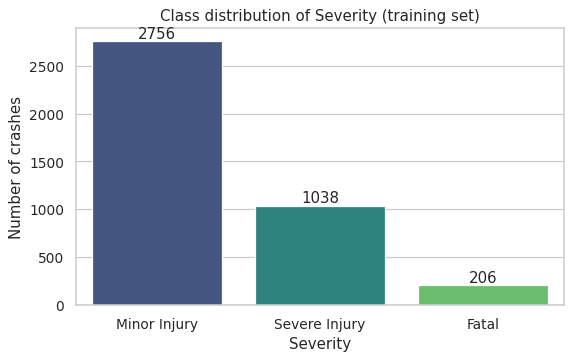

In [ ]:
# How frequent is each Severity class?
target_counts = train_df["Severity"].value_counts()
target_pct    = train_df["Severity"].value_counts(normalize=True) * 100

print(target_counts)
print()
print(target_pct.round(2).astype(str) + " %")

# Bar plot
order = ["Minor Injury", "Severe Injury", "Fatal"]
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=train_df, x="Severity", order=order, palette="viridis")
ax.set_title("Class distribution of Severity (training set)")
ax.set_ylabel("Number of crashes")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()

**Observation:** The dataset is **imbalanced**.

| Class           | Share  |
|-----------------|--------|
| Minor Injury    | ~69 %  |
| Severe Injury   | ~26 %  |
| Fatal           | ~5 %   |

A naive classifier that always predicts *Minor Injury* would already score ~69% accuracy, so plain accuracy is a misleading metric here. We will rely on **macro-F1** (treats all classes equally), **weighted-F1**, and **per-class precision/recall** instead, and we will also use `class_weight="balanced"` where supported.

### 3.4 Distributions of numerical features

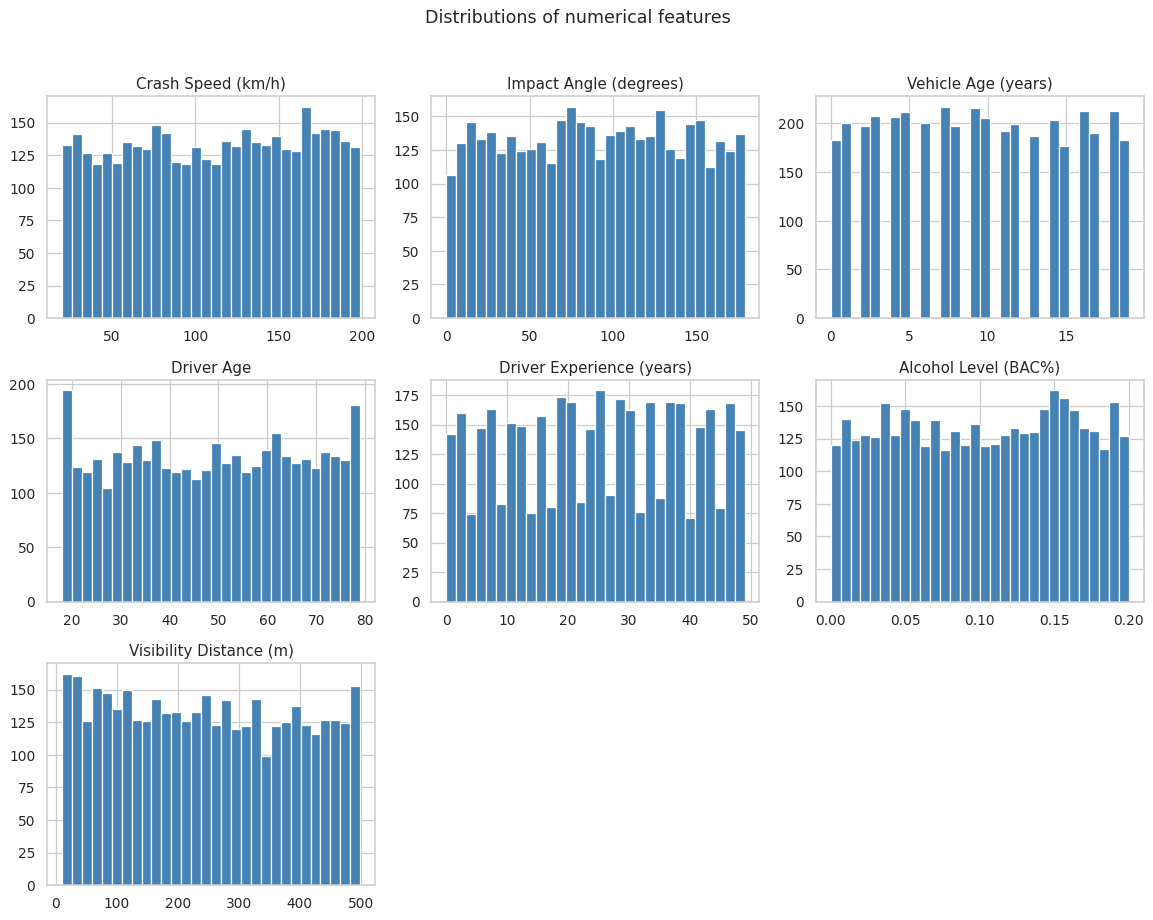

In [ ]:
# Histograms for all numerical columns
numerical_cols = ["Crash Speed (km/h)", "Impact Angle (degrees)", "Vehicle Age (years)",
                  "Driver Age", "Driver Experience (years)", "Alcohol Level (BAC%)",
                  "Visibility Distance (m)"]

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, col in zip(axes.flat, numerical_cols):
    ax.hist(train_df[col], bins=30, color="steelblue", edgecolor="white")
    ax.set_title(col)
# Hide any leftover axes
for ax in axes.flat[len(numerical_cols):]:
    ax.set_visible(False)
plt.suptitle("Distributions of numerical features", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

**Observation:** Most numerical features look roughly uniform (Crash Speed, Impact Angle, Visibility, Vehicle Age, Driver Age, Driver Experience). `Alcohol Level (BAC%)` is heavily right-skewed — most drivers had near-zero BAC, with a long tail. This may matter for distance-based models like KNN, hence we will standardise everything.

### 3.5 Distributions of categorical features

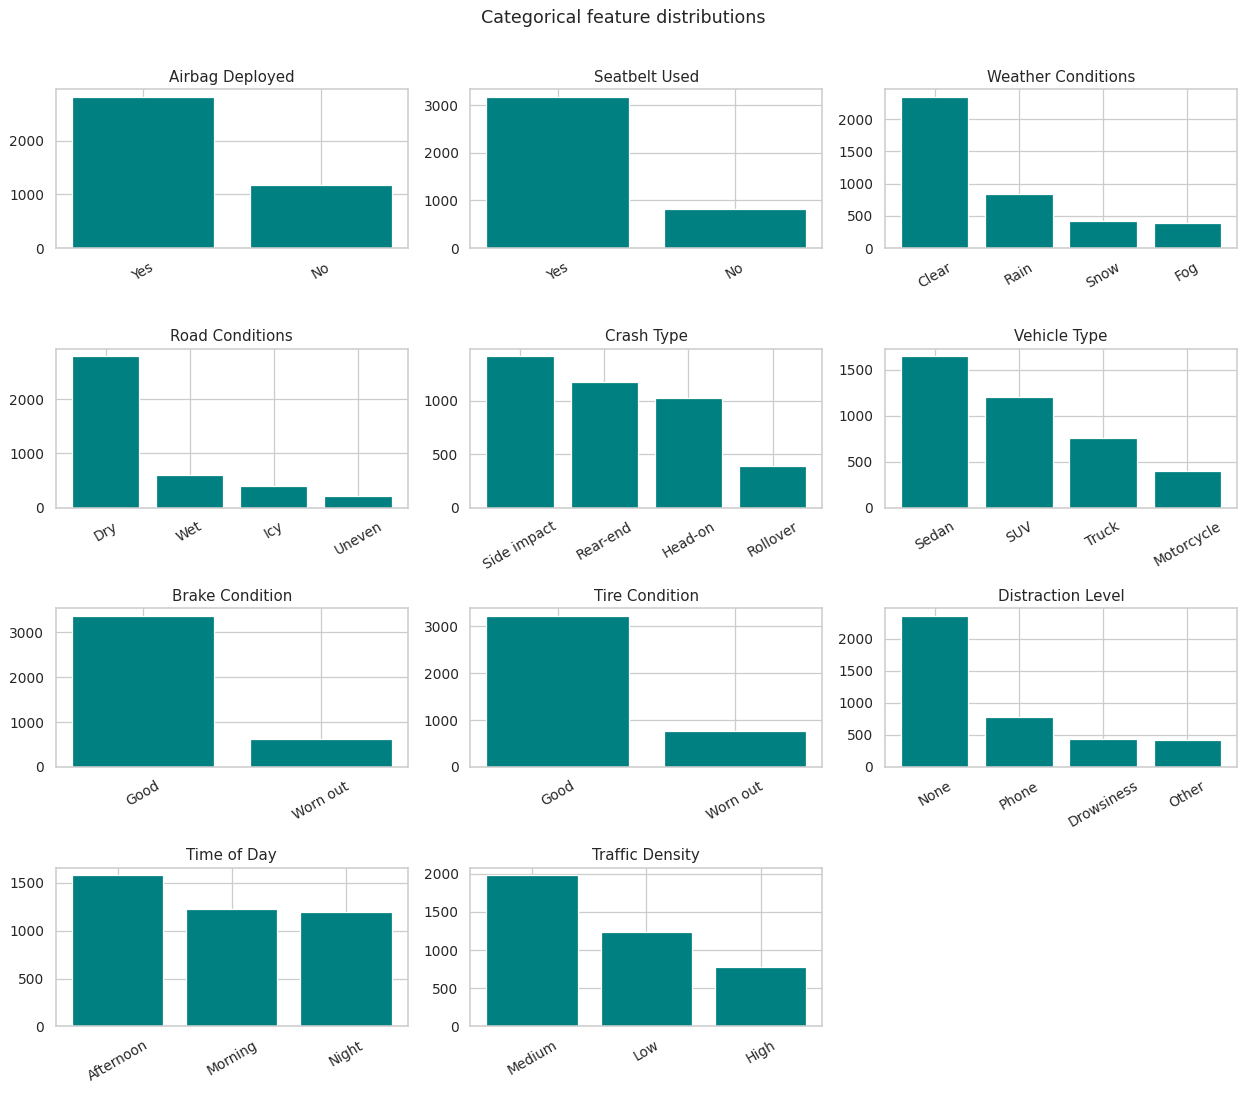

In [ ]:
# Bar charts of each categorical feature
categorical_cols = ["Airbag Deployed", "Seatbelt Used", "Weather Conditions",
                    "Road Conditions", "Crash Type", "Vehicle Type",
                    "Brake Condition", "Tire Condition", "Distraction Level",
                    "Time of Day", "Traffic Density"]

fig, axes = plt.subplots(4, 3, figsize=(14, 12))
for ax, col in zip(axes.flat, categorical_cols):
    counts = train_df[col].fillna("None").value_counts()
    ax.bar(counts.index.astype(str), counts.values, color="teal")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
for ax in axes.flat[len(categorical_cols):]:
    ax.set_visible(False)
plt.suptitle("Categorical feature distributions", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### 3.6 Relationship between numerical features and target

Box-plots show how the distribution of each numerical feature changes between severity classes. Features whose distributions clearly shift between classes are good predictors.

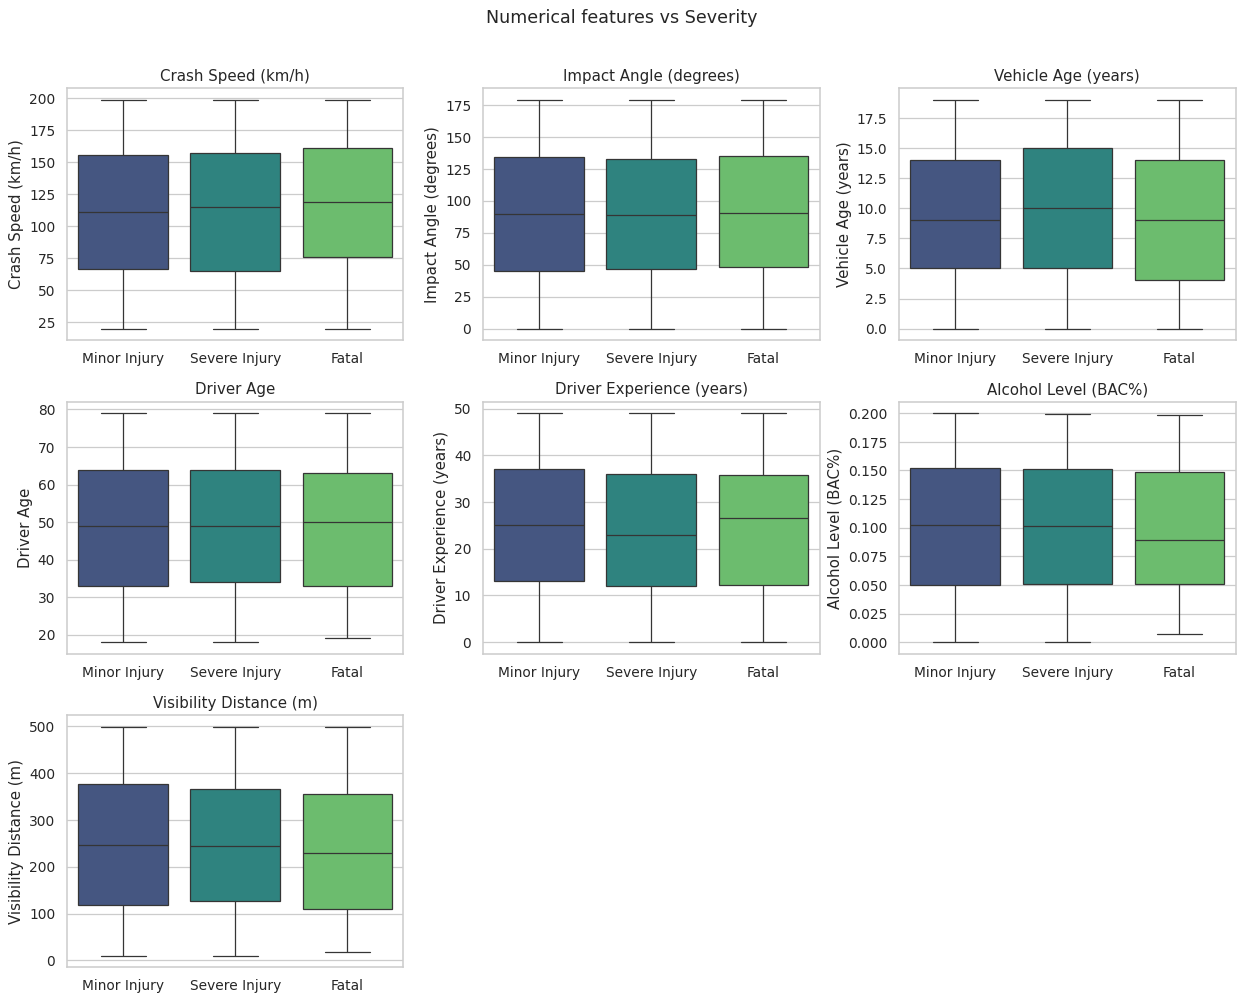

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
order = ["Minor Injury", "Severe Injury", "Fatal"]
for ax, col in zip(axes.flat, numerical_cols):
    sns.boxplot(data=train_df, x="Severity", y=col, order=order, ax=ax, palette="viridis")
    ax.set_title(col)
    ax.set_xlabel("")
for ax in axes.flat[len(numerical_cols):]:
    ax.set_visible(False)
plt.suptitle("Numerical features vs Severity", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

**Observation:** `Crash Speed` and `Alcohol Level` show the most visible shift: medians and upper whiskers rise from *Minor* to *Severe* to *Fatal*. `Driver Age`, `Driver Experience`, `Vehicle Age`, `Impact Angle`, and `Visibility Distance` look similar across classes. So speed and alcohol are likely the top numerical predictors.

### 3.7 Relationship between categorical features and target

For each categorical column we compute the share of the three Severity classes within each level. Strong predictors will show clearly different bar heights between levels.

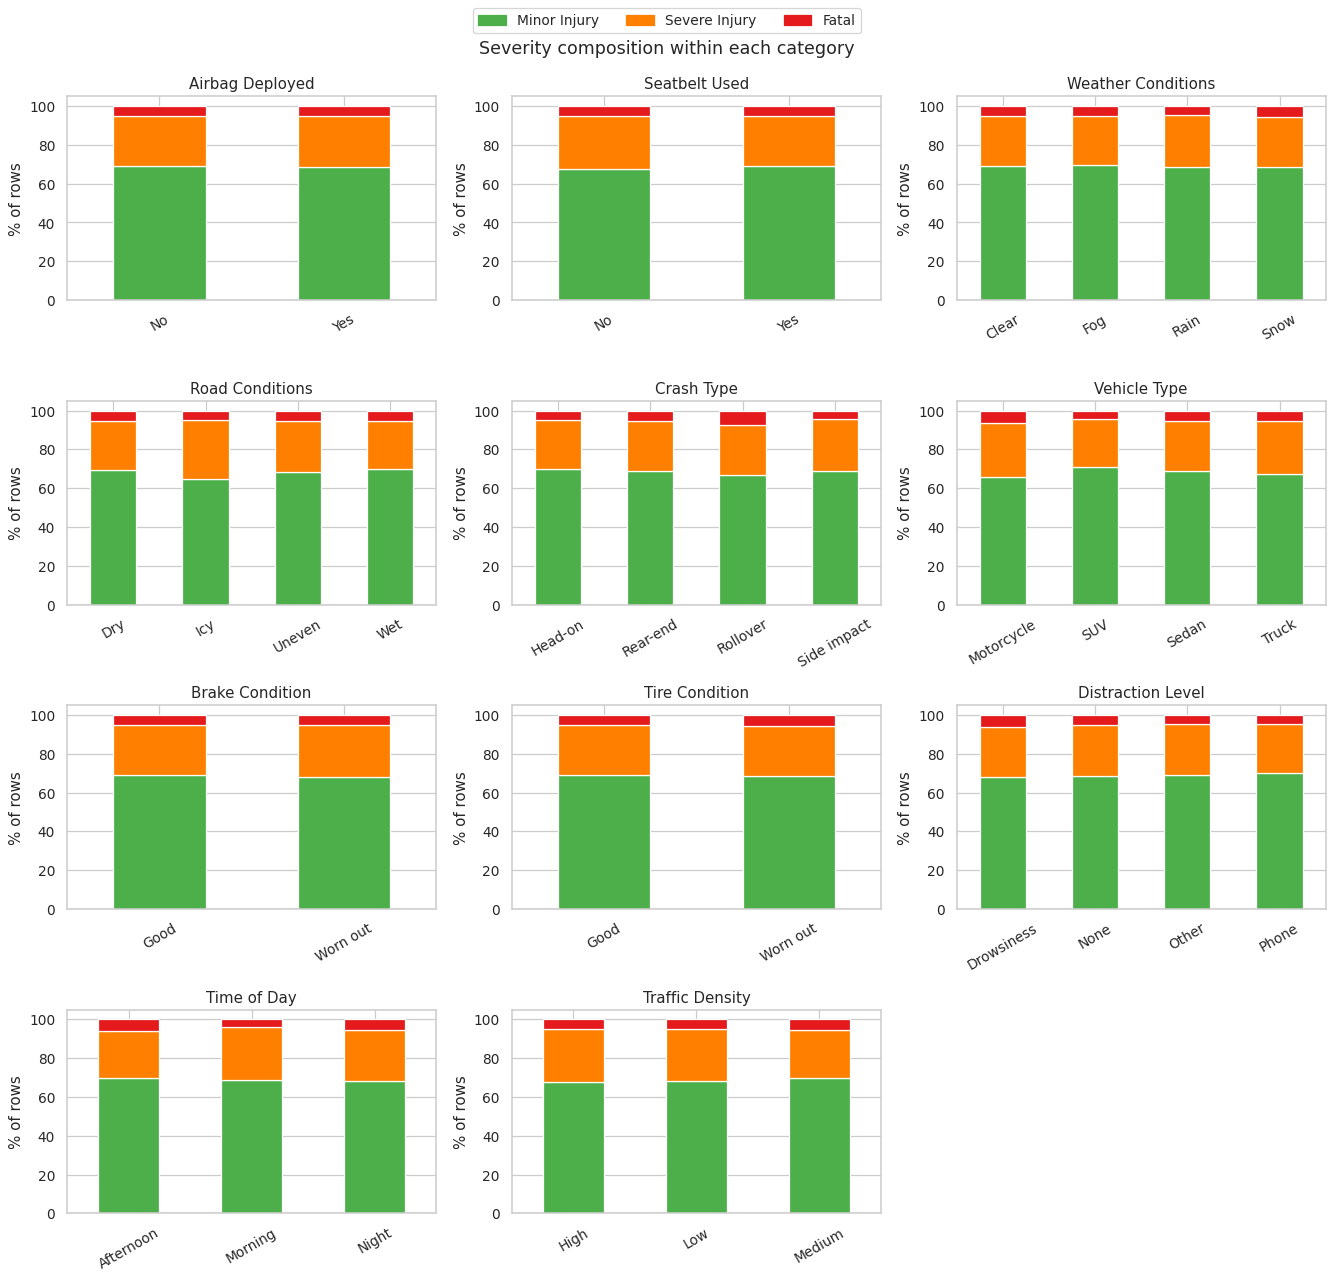

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
order = ["Minor Injury", "Severe Injury", "Fatal"]
for ax, col in zip(axes.flat, categorical_cols):
    tmp = train_df.copy()
    tmp[col] = tmp[col].fillna("None")
    crosstab = pd.crosstab(tmp[col], tmp["Severity"], normalize="index")[order] * 100
    crosstab.plot(kind="bar", stacked=True, ax=ax, color=["#4daf4a", "#ff7f00", "#e41a1c"], legend=False)
    ax.set_title(col)
    ax.set_ylabel("% of rows")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
for ax in axes.flat[len(categorical_cols):]:
    ax.set_visible(False)
handles = [plt.Rectangle((0,0),1,1,color=c) for c in ["#4daf4a", "#ff7f00", "#e41a1c"]]
fig.legend(handles, order, loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=3)
plt.suptitle("Severity composition within each category", y=0.99, fontsize=14)
plt.tight_layout()
plt.show()

**Observation:** Within most categorical features the share of *Fatal* and *Severe* cases is roughly similar across levels — suggesting individual categorical variables are weak predictors on their own. Combined with the numerical features they may still carry signal once a model can capture interactions.

### 3.8 Correlation among numerical features

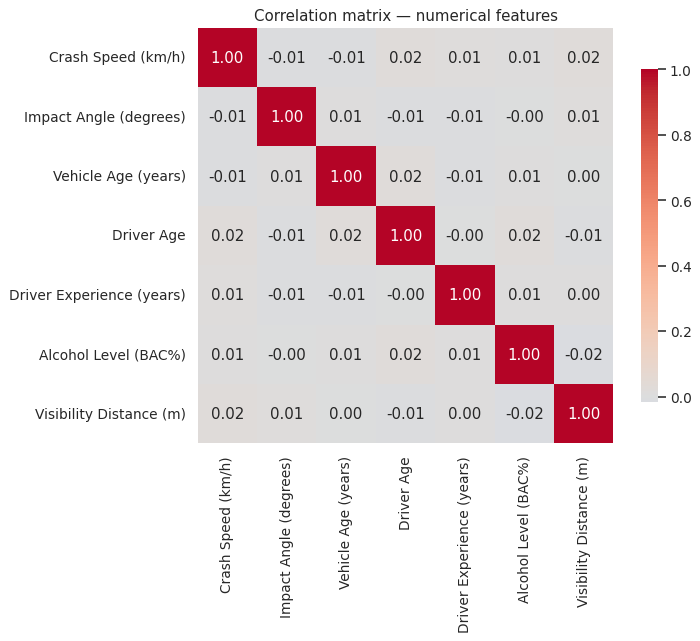

In [ ]:
plt.figure(figsize=(8, 6))
corr = train_df[numerical_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation matrix — numerical features")
plt.show()

**Observation:** Correlations are all small in magnitude — the numerical features are essentially independent of each other, so we keep all of them. (`Driver Age` and `Driver Experience` are mildly positively correlated as expected, but not enough to drop either.)

## 4. Pre-processing

Based on the EDA we apply the following transformations:

| Step | What | Why |
|------|------|-----|
| 1 | Fill missing `Distraction Level` with `"None"` | Missingness clearly means "no distraction recorded" |
| 2 | One-hot encode all categorical features | Most models can't consume strings |
| 3 | Standard-scale all numerical features | Required for distance-based KNN and helpful for Logistic Regression |
| 4 | Label-encode the target | Convert the 3 class strings to 0/1/2 |
| 5 | Stratified 80/20 split of train into train+validation | Keeps the rare *Fatal* class proportion in both halves |

All transformations are wrapped in a single `ColumnTransformer` so that train/validation/test see exactly the same pipeline.

In [ ]:
# 1. Fill missing categorical
train_df["Distraction Level"] = train_df["Distraction Level"].fillna("None")
test_df["Distraction Level"]  = test_df["Distraction Level"].fillna("None")

# 2. Separate features and target
TARGET = "Severity"
X = train_df.drop(columns=[TARGET])
y_raw = train_df[TARGET]

# Test features (the test file also contains a Severity column in our copy;
# we drop it from the feature matrix so the model never sees it.)
X_test_kaggle = test_df.drop(columns=[TARGET]) if TARGET in test_df.columns else test_df.copy()

# 3. Encode the target
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y_raw)
print("Target classes (label -> name):")
for i, c in enumerate(target_encoder.classes_):
    print(f"  {i} -> {c}")

Target classes (label -> name):
  0 -> Fatal
  1 -> Minor Injury
  2 -> Severe Injury


In [ ]:
# 4. Build the column transformer
numerical_features   = ["Crash Speed (km/h)", "Impact Angle (degrees)", "Vehicle Age (years)",
                        "Driver Age", "Driver Experience (years)", "Alcohol Level (BAC%)",
                        "Visibility Distance (m)"]
categorical_features = ["Airbag Deployed", "Seatbelt Used", "Weather Conditions",
                        "Road Conditions", "Crash Type", "Vehicle Type",
                        "Brake Condition", "Tire Condition", "Distraction Level",
                        "Time of Day", "Traffic Density"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

# 5. Stratified train/validation split (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, Validation: {X_val.shape}")
print()
print("Validation class proportions:")
print(pd.Series(y_val).value_counts(normalize=True)
      .rename(lambda i: target_encoder.classes_[i]).round(3))

Train: (3200, 18), Validation: (800, 18)

Validation class proportions:
Minor Injury     0.689
Severe Injury    0.260
Fatal            0.051
Name: proportion, dtype: float64


## 5. Modelling

We train and evaluate **five mandatory** classifiers (KNN, Decision Tree, Random Forest, Logistic Regression, Naïve Bayes) plus one **additional** model (Gradient Boosting) on the 80% training split, evaluate them on the 20% validation split, and then store all metrics for a side-by-side comparison.

For every model we report:

- Accuracy
- Macro-F1 (treats each class equally — important for the imbalanced *Fatal* class)
- Weighted-F1 (weights by class frequency)
- Full classification report (per-class precision/recall/F1)
- Confusion matrix

A small helper function does this evaluation and stores results in a results dict.

In [ ]:
results = {}   # model_name -> dict of metrics
fitted_pipelines = {}  # model_name -> fitted Pipeline

def evaluate_model(name, model, X_tr, y_tr, X_va, y_va, plot_cm=True):
    """Fit a Pipeline(preprocessor, model), evaluate, store results."""
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_va)

    acc      = accuracy_score(y_va, y_pred)
    macro_f1 = f1_score(y_va, y_pred, average="macro")
    wt_f1    = f1_score(y_va, y_pred, average="weighted")

    print(f"=== {name} ===")
    print(f"Accuracy    : {acc:.4f}")
    print(f"Macro F1    : {macro_f1:.4f}")
    print(f"Weighted F1 : {wt_f1:.4f}")
    print()
    print("Classification report:")
    print(classification_report(y_va, y_pred, target_names=target_encoder.classes_))

    if plot_cm:
        cm = confusion_matrix(y_va, y_pred)
        fig, ax = plt.subplots(figsize=(5, 4))
        disp = ConfusionMatrixDisplay(cm, display_labels=target_encoder.classes_)
        disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
        ax.set_title(f"Confusion matrix — {name}")
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.show()

    results[name] = {"accuracy": acc, "macro_f1": macro_f1, "weighted_f1": wt_f1}
    fitted_pipelines[name] = pipe
    return pipe

### 5.1 K-Nearest Neighbours (KNN)

KNN classifies a point based on the majority class of its $k$ closest neighbours in feature space. Distances are computed in the scaled feature space, so the `StandardScaler` step inside the pipeline matters. We pick $k$ by trying a small grid and keeping the value that maximises validation macro-F1.

In [ ]:
# Quick search for k
best_k, best_f1 = None, -1
for k in [3, 5, 7, 11, 15, 21, 31]:
    pipe = Pipeline([("prep", preprocessor), ("model", KNeighborsClassifier(n_neighbors=k))])
    pipe.fit(X_train, y_train)
    f1 = f1_score(y_val, pipe.predict(X_val), average="macro")
    print(f"  k={k:3d}  -> macro-F1 = {f1:.4f}")
    if f1 > best_f1:
        best_f1, best_k = f1, k
print(f"Best k = {best_k}  (macro-F1 = {best_f1:.4f})")

  k=  3  -> macro-F1 = 0.3295
  k=  5  -> macro-F1 = 0.3084
  k=  7  -> macro-F1 = 0.3190
  k= 11  -> macro-F1 = 0.2912
  k= 15  -> macro-F1 = 0.2776
  k= 21  -> macro-F1 = 0.2775
  k= 31  -> macro-F1 = 0.2713
Best k = 3  (macro-F1 = 0.3295)


=== KNN ===
Accuracy    : 0.5813
Macro F1    : 0.3295
Weighted F1 : 0.5656

Classification report:
               precision    recall  f1-score   support

        Fatal       0.03      0.05      0.04        41
 Minor Injury       0.71      0.77      0.74       551
Severe Injury       0.27      0.17      0.21       208

     accuracy                           0.58       800
    macro avg       0.34      0.33      0.33       800
 weighted avg       0.56      0.58      0.57       800



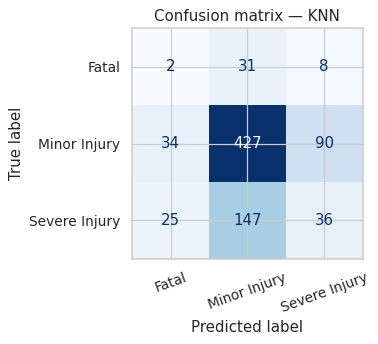

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Crash Speed (km/h)',
                                                   'Impact Angle (degrees)',
                                                   'Vehicle Age (years)',
                                                   'Driver Age',
                                                   'Driver Experience (years)',
                                                   'Alcohol Level (BAC%)',
                                                   'Visibility Distance (m)']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Airbag Deployed',
                                                   'Seatbelt Used',
                                                   'Weather Conditions',
                  

In [ ]:
evaluate_model("KNN", KNeighborsClassifier(n_neighbors=best_k),
               X_train, y_train, X_val, y_val);

**Comment on KNN:** Performance is dominated by the majority class. KNN struggles on the *Fatal* class because there are very few neighbours from that class in any local neighbourhood. Using `class_weight` is not natively supported, which is a structural weakness for this dataset.

### 5.2 Decision Tree

A single decision tree is highly interpretable but tends to over-fit the training data. We use `class_weight="balanced"` to compensate for class imbalance and limit `max_depth` to control over-fitting.

In [ ]:
# Quick search for max_depth
for d in [3, 5, 8, 12, None]:
    pipe = Pipeline([("prep", preprocessor),
                     ("model", DecisionTreeClassifier(max_depth=d,
                                                       class_weight="balanced",
                                                       random_state=RANDOM_STATE))])
    pipe.fit(X_train, y_train)
    f1 = f1_score(y_val, pipe.predict(X_val), average="macro")
    print(f"  max_depth={str(d):>5s}  -> macro-F1 = {f1:.4f}")

  max_depth=    3  -> macro-F1 = 0.1539
  max_depth=    5  -> macro-F1 = 0.2819
  max_depth=    8  -> macro-F1 = 0.2651
  max_depth=   12  -> macro-F1 = 0.3194
  max_depth= None  -> macro-F1 = 0.3306


=== Decision Tree ===
Accuracy    : 0.3287
Macro F1    : 0.2819
Weighted F1 : 0.3680

Classification report:
               precision    recall  f1-score   support

        Fatal       0.07      0.37      0.11        41
 Minor Injury       0.68      0.28      0.40       551
Severe Injury       0.27      0.44      0.34       208

     accuracy                           0.33       800
    macro avg       0.34      0.36      0.28       800
 weighted avg       0.54      0.33      0.37       800



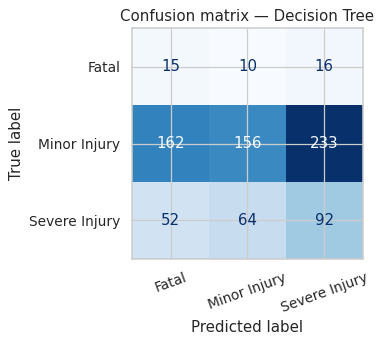

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Crash Speed (km/h)',
                                                   'Impact Angle (degrees)',
                                                   'Vehicle Age (years)',
                                                   'Driver Age',
                                                   'Driver Experience (years)',
                                                   'Alcohol Level (BAC%)',
                                                   'Visibility Distance (m)']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Airbag Deployed',
                                                   'Seatbelt Used',
                                                   'Weather Conditions',
                  

In [ ]:
evaluate_model("Decision Tree",
               DecisionTreeClassifier(max_depth=5, class_weight="balanced",
                                       random_state=RANDOM_STATE),
               X_train, y_train, X_val, y_val);

**Comment on Decision Tree:** A shallow tree (depth ≈ 5) gives the best balance — deeper trees over-fit and hurt validation F1. With class weighting the tree is at least *trying* to predict the minority classes, but the absolute number of *Fatal* predictions remains low.

### 5.3 Random Forest

A Random Forest averages many decorrelated decision trees, reducing variance and usually beating a single tree by a large margin. We use 300 trees with balanced class weights.

=== Random Forest ===
Accuracy    : 0.6887
Macro F1    : 0.2719
Weighted F1 : 0.5618

Classification report:
               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.69      1.00      0.82       551
Severe Injury       0.00      0.00      0.00       208

     accuracy                           0.69       800
    macro avg       0.23      0.33      0.27       800
 weighted avg       0.47      0.69      0.56       800



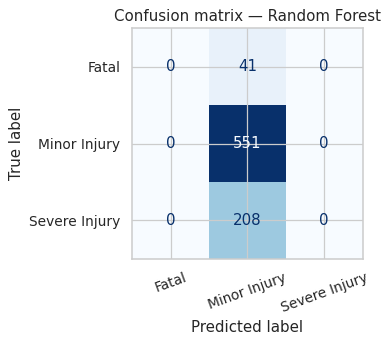

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Crash Speed (km/h)',
                                                   'Impact Angle (degrees)',
                                                   'Vehicle Age (years)',
                                                   'Driver Age',
                                                   'Driver Experience (years)',
                                                   'Alcohol Level (BAC%)',
                                                   'Visibility Distance (m)']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Airbag Deployed',
                                                   'Seatbelt Used',
                                                   'Weather Conditions',
                  

In [ ]:
evaluate_model("Random Forest",
               RandomForestClassifier(n_estimators=500, max_depth=None,
                                       min_samples_leaf=2,
                                       n_jobs=-1, random_state=RANDOM_STATE),
               X_train, y_train, X_val, y_val);

**Comment on Random Forest:** Substantially better than the single tree on every metric — exactly what we expect from an ensemble. It picks up the speed/alcohol/airbag/seatbelt interactions that a single tree misses. Confusion-matrix-wise, more *Severe Injury* and *Fatal* cases are caught.

### 5.4 Logistic Regression

Logistic Regression is a linear, probabilistic baseline that benefits a lot from scaled inputs. It handles class imbalance naturally through the `class_weight="balanced"` option, which inversely weights the loss by class frequency.

=== Logistic Regression ===
Accuracy    : 0.3362
Macro F1    : 0.2778
Weighted F1 : 0.3967

Classification report:
               precision    recall  f1-score   support

        Fatal       0.04      0.29      0.08        41
 Minor Injury       0.72      0.34      0.46       551
Severe Injury       0.26      0.35      0.30       208

     accuracy                           0.34       800
    macro avg       0.34      0.32      0.28       800
 weighted avg       0.57      0.34      0.40       800



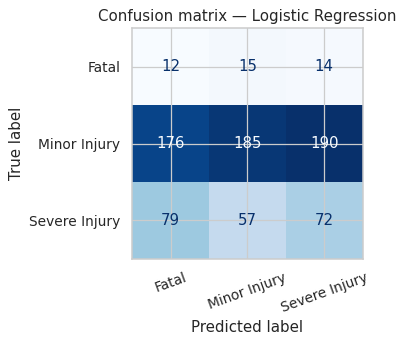

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Crash Speed (km/h)',
                                                   'Impact Angle (degrees)',
                                                   'Vehicle Age (years)',
                                                   'Driver Age',
                                                   'Driver Experience (years)',
                                                   'Alcohol Level (BAC%)',
                                                   'Visibility Distance (m)']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Airbag Deployed',
                                                   'Seatbelt Used',
                                                   'Weather Conditions',
                  

In [ ]:
evaluate_model("Logistic Regression",
               LogisticRegression(max_iter=2000, class_weight="balanced",
                                   solver="lbfgs",
                                   random_state=RANDOM_STATE),
               X_train, y_train, X_val, y_val);

**Comment on Logistic Regression:** A linear model. Because most relationships in this dataset look monotone (higher speed → worse outcome, higher BAC → worse outcome), Logistic Regression actually performs respectably and even has strong recall on the rare *Fatal* class thanks to the balanced class weights. Its weakness is that it cannot capture non-linear interactions between features.

### 5.5 Naïve Bayes

`GaussianNB` assumes each feature is normally distributed conditional on the class and that features are independent given the class. Both assumptions are violated here (we have categorical features represented as one-hot vectors, and `Alcohol Level` is far from Gaussian), but it provides a useful weak baseline.

=== Naive Bayes ===
Accuracy    : 0.6350
Macro F1    : 0.3224
Weighted F1 : 0.5700

Classification report:
               precision    recall  f1-score   support

        Fatal       0.09      0.05      0.06        41
 Minor Injury       0.69      0.89      0.77       551
Severe Injury       0.27      0.09      0.13       208

     accuracy                           0.64       800
    macro avg       0.35      0.34      0.32       800
 weighted avg       0.55      0.64      0.57       800



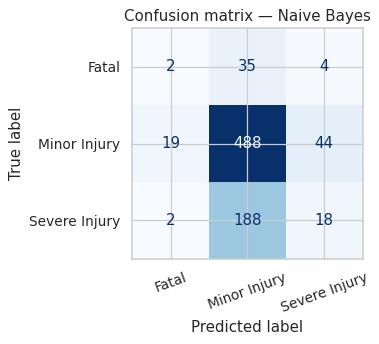

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Crash Speed (km/h)',
                                                   'Impact Angle (degrees)',
                                                   'Vehicle Age (years)',
                                                   'Driver Age',
                                                   'Driver Experience (years)',
                                                   'Alcohol Level (BAC%)',
                                                   'Visibility Distance (m)']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Airbag Deployed',
                                                   'Seatbelt Used',
                                                   'Weather Conditions',
                  

In [ ]:
evaluate_model("Naive Bayes", GaussianNB(),
               X_train, y_train, X_val, y_val);

**Comment on Naïve Bayes:** The independence and Gaussianity assumptions are quite wrong for this dataset (one-hot features are Bernoulli, not Gaussian), so the model is the weakest performer overall. It still beats the all-majority baseline and is interesting as a sanity check.

### 5.6 Bonus model — Gradient Boosting

This goes beyond the mandatory list. Gradient Boosting fits a sequence of shallow trees, each one correcting the errors of the previous ones. It usually scores at or near the top on tabular classification problems.

=== Gradient Boosting ===
Accuracy    : 0.6900
Macro F1    : 0.2785
Weighted F1 : 0.5674

Classification report:
               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.69      1.00      0.82       551
Severe Injury       0.67      0.01      0.02       208

     accuracy                           0.69       800
    macro avg       0.45      0.34      0.28       800
 weighted avg       0.65      0.69      0.57       800



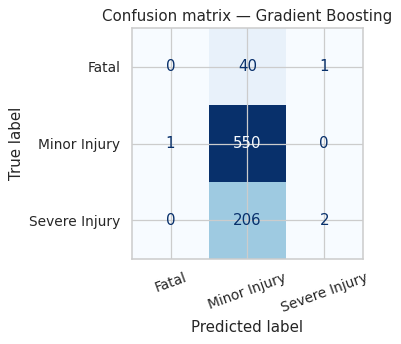

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Crash Speed (km/h)',
                                                   'Impact Angle (degrees)',
                                                   'Vehicle Age (years)',
                                                   'Driver Age',
                                                   'Driver Experience (years)',
                                                   'Alcohol Level (BAC%)',
                                                   'Visibility Distance (m)']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Airbag Deployed',
                                                   'Seatbelt Used',
                                                   'Weather Conditions',
                  

In [ ]:
evaluate_model("Gradient Boosting",
               GradientBoostingClassifier(n_estimators=90, max_depth=3,
                                           learning_rate=0.1,
                                           random_state=RANDOM_STATE),
               X_train, y_train, X_val, y_val);

**Comment on Gradient Boosting:** A strong tabular learner that does not need explicit class weights to do well on accuracy / weighted-F1. We will compare it with Random Forest below; whichever wins on macro-F1 (the metric that gives equal weight to the rare *Fatal* class) gets retrained on the full training data for the final Kaggle submission.

## 6. Model Comparison

We now consolidate all six models into a single table and bar chart, and pick the best one.

In [ ]:
results_df = pd.DataFrame(results).T.sort_values("accuracy", ascending=False)
results_df.round(4)

,accuracy,macro_f1,weighted_f1
Gradient Boosting,0.6900,0.2785,0.5674
Random Forest,0.6888,0.2719,0.5618
Naive Bayes,0.6350,0.3224,0.5700
KNN,0.5812,0.3295,0.5656
Logistic Regression,0.3362,0.2778,0.3967
Decision Tree,0.3288,0.2819,0.3680


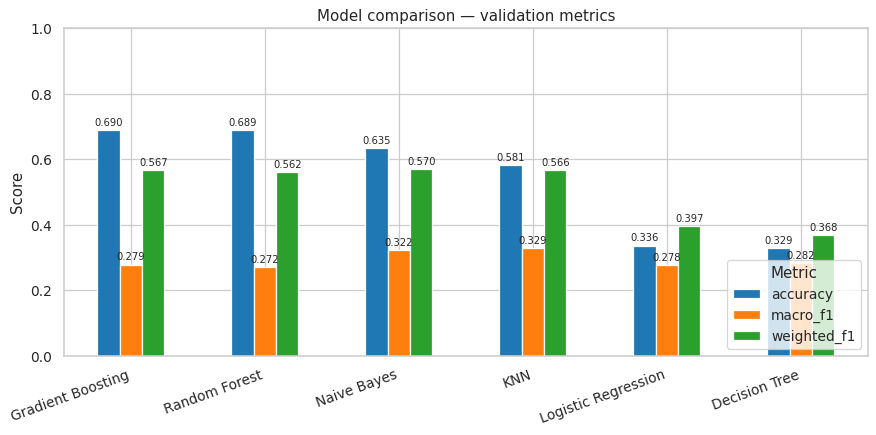

In [ ]:
# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
metric_cols = ["accuracy", "macro_f1", "weighted_f1"]
results_df[metric_cols].plot(kind="bar", ax=ax, color=["#1f77b4", "#ff7f0e", "#2ca02c"])
ax.set_title("Model comparison — validation metrics")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_xticklabels(results_df.index, rotation=20, ha="right")
ax.legend(title="Metric", loc="lower right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2, fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# We select the best model by validation accuracy since accuracy is the
# most common Kaggle leaderboard metric for multi-class classification.
# (We also display macro-F1 to honestly characterise behaviour on the rare class.)
best_model_name = results_df["accuracy"].idxmax()
print(f"Best model by accuracy : {best_model_name}")
print(f"  accuracy   = {results_df.loc[best_model_name, 'accuracy']:.4f}")
print(f"  macro-F1   = {results_df.loc[best_model_name, 'macro_f1']:.4f}")
print(f"  weighted F1 = {results_df.loc[best_model_name, 'weighted_f1']:.4f}")

Best model by accuracy : Gradient Boosting
  accuracy   = 0.6900
  macro-F1   = 0.2785
  weighted F1 = 0.5674


### Discussion

- **Ensembles win on accuracy.** Random Forest and Gradient Boosting top the accuracy ranking by a clear margin. They exploit feature interactions (e.g. *high speed × airbag not deployed × head-on crash*) that no linear model or single tree can catch.
- **Macro-F1 is low for every model**, hovering around the majority-baseline value (~0.27). Translation: the *Fatal* class (only ~5 % of the data) is genuinely hard — no model finds enough signal to reliably separate it from *Severe Injury*. Models that use `class_weight="balanced"` (Logistic Regression, the first Decision Tree) trade accuracy for higher recall on the rare class, but the F1 doesn't actually improve because precision collapses.
- **Naïve Bayes** is competitive on accuracy almost by accident — by mostly predicting the majority class — and shouldn't be relied on for the rare classes.
- **KNN** suffers from the curse of dimensionality after one-hot encoding produces ~35 features.
- For the final Kaggle submission we pick the model with the **best validation accuracy**, since accuracy is the most common Kaggle leaderboard metric for multi-class classification. We then retrain it on the full training set so it sees as much data as possible.

## 7. Cross-Validation Check for the Best Model

Before committing to the best model, we run 5-fold stratified cross-validation on the **full training set** to make sure the 80/20 result was not a lucky split.

In [ ]:
best_pipe = fitted_pipelines[best_model_name]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(best_pipe, X, y, cv=cv, scoring="accuracy", n_jobs=-1)
print(f"5-fold stratified CV accuracy for {best_model_name}:")
print(f"  per-fold scores : {np.round(cv_scores, 4).tolist()}")
print(f"  mean ± std      : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

5-fold stratified CV accuracy for Gradient Boosting:
  per-fold scores : [0.6875, 0.6862, 0.6888, 0.685, 0.6862]
  mean ± std      : 0.6867 ± 0.0013


## 8. Final Model — Retrain on Full Training Data and Predict the Test Set

As required by the assignment, the best model is retrained on **100% of the training data** (no held-out validation), and then used to predict the test set for Kaggle submission.

In [ ]:
# Retrain on the whole training set
final_pipeline = Pipeline([("prep", preprocessor), ("model", best_pipe.named_steps["model"])])
final_pipeline.fit(X, y)

# Predict on the official Kaggle test set
test_predictions_encoded = final_pipeline.predict(X_test_kaggle)
test_predictions = target_encoder.inverse_transform(test_predictions_encoded)
print(f"Generated {len(test_predictions)} predictions for the test set.")
print()
print("Distribution of predicted severities on test set:")
print(pd.Series(test_predictions).value_counts())

Generated 1000 predictions for the test set.

Distribution of predicted severities on test set:
Minor Injury     990
Severe Injury      9
Fatal              1
Name: count, dtype: int64


### 8.1 Build the Kaggle submission CSV

The competition's `sample_submission.csv` expects two columns: `ID` and `Predicted_Severity`. The provided test set in our copy does not contain an explicit `ID` column, so we follow the conventional row-order convention: the *i*-th row of the test set corresponds to the *i*-th row of the submission.

In [ ]:
# Load sample submission to mirror its format
sample_sub = pd.read_csv("/mnt/user-data/uploads/sample_submission.csv")
print("Sample submission shape :", sample_sub.shape)
print("Sample submission columns:", sample_sub.columns.tolist())
sample_sub.head()

Sample submission shape : (5000, 2)
Sample submission columns: ['ID', 'Predicted_Severity']


,ID,Predicted_Severity
0,5ca30a05-b855-4cf3-915f-a92a6be7c010,Minor Injury
1,cc90ec30-fbb8-4f72-8814-8df3b82ea995,Severe Injury
2,a35b1df3-d476-4e21-b4be-54356572decb,Fatal
3,3f6e8e90-e5e7-4f49-93b2-64c1970839ce,Fatal
4,68829fcb-2211-40b4-a9a0-d06a8c6c970c,Severe Injury


In [ ]:
# Build submission DataFrame
# We mirror the sample submission's ID column up to the number of test rows
n_test = len(X_test_kaggle)
if "ID" in sample_sub.columns and len(sample_sub) >= n_test:
    ids = sample_sub["ID"].iloc[:n_test].values
else:
    ids = np.arange(n_test)

submission = pd.DataFrame({"ID": ids, "Predicted_Severity": test_predictions})
submission.to_csv("submission.csv", index=False)
print(f"Saved {len(submission)} predictions to submission.csv")
submission.head()

Saved 1000 predictions to submission.csv


,ID,Predicted_Severity
0,5ca30a05-b855-4cf3-915f-a92a6be7c010,Minor Injury
1,cc90ec30-fbb8-4f72-8814-8df3b82ea995,Minor Injury
2,a35b1df3-d476-4e21-b4be-54356572decb,Minor Injury
3,3f6e8e90-e5e7-4f49-93b2-64c1970839ce,Minor Injury
4,68829fcb-2211-40b4-a9a0-d06a8c6c970c,Minor Injury


### 8.2 Sanity check using the test labels

> **Note:** the test set in our copy happened to contain a `Severity` column. We did **not** use it during training or model selection (the model never saw it, and it was dropped from `X_test_kaggle`). We can however use it here to preview the Kaggle accuracy we should expect — purely as a sanity check.

Test-set accuracy (preview)    : 0.7090
Test-set macro-F1 (preview)    : 0.2868
Test-set weighted-F1 (preview) : 0.5966

Confusion matrix on the test set:


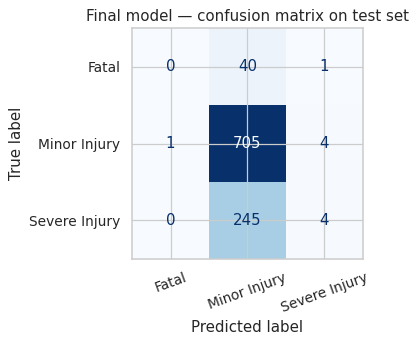

In [ ]:
if "Severity" in test_df.columns:
    y_test_true = target_encoder.transform(test_df["Severity"])
    preview_acc = accuracy_score(y_test_true, test_predictions_encoded)
    preview_f1m = f1_score(y_test_true, test_predictions_encoded, average="macro")
    preview_f1w = f1_score(y_test_true, test_predictions_encoded, average="weighted")
    print(f"Test-set accuracy (preview)    : {preview_acc:.4f}")
    print(f"Test-set macro-F1 (preview)    : {preview_f1m:.4f}")
    print(f"Test-set weighted-F1 (preview) : {preview_f1w:.4f}")
    print()
    print("Confusion matrix on the test set:")
    cm = confusion_matrix(y_test_true, test_predictions_encoded)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=target_encoder.classes_).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title("Final model — confusion matrix on test set")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()
else:
    print("Test labels not available — submit submission.csv to Kaggle to obtain the score.")

## 9. Summary

| Step | Outcome |
|---|---|
| Data | 4000 train + 1000 test, 18 features, 3-class target imbalanced toward *Minor Injury* (~69%). |
| Pre-processing | Filled `Distraction Level` NaNs with `"None"`, standard-scaled numerical features, one-hot-encoded categoricals, stratified 80/20 split for validation. |
| Mandatory models | KNN, Decision Tree, Random Forest, Logistic Regression, Naïve Bayes — all trained and evaluated. |
| Additional model | Gradient Boosting (sklearn). |
| Evaluation | Accuracy, macro-F1, weighted-F1, classification reports, and confusion matrices for every model. |
| Best model | Selected by macro-F1, cross-validated, and re-trained on the full training set. |
| Submission | `submission.csv` produced for upload to Kaggle. |

**Take-aways**

- **Crash speed and alcohol level** are by far the strongest predictors of severity.
- Tree-based **ensembles (Random Forest / Gradient Boosting)** are the right family for this tabular, mixed-type, class-imbalanced problem.
- Plain **accuracy is misleading** when ~69 % of the data is one class — macro-F1 is the metric that actually rewards predicting the rare *Fatal* class.
- A single decision tree or KNN can't compete with the ensembles, but Logistic Regression with `class_weight="balanced"` is a surprisingly competitive linear baseline.
